# Coach IA — Notebook à étudier

**Module APIE638 — Atelier API IA — EPSI Bachelor SIN 3ème année**

---

## Votre mission

Ce notebook contient un coach sportif IA complet et fonctionnel : il reçoit une séance d'un sportif débutant, détecte des signaux faibles dans son ressenti, et lui répond avec un ton adapté (chaleureux, motivant, doux, ou alerte). Il utilise **LangChain**, **LangGraph** et l'**API Mistral**.

### Ce que vous devez faire

| Phase | Activité | Durée |
|---|---|---|
| 1. Lire et exécuter | Faire tourner toutes les cellules, observer les sorties, modifier les inputs pour expérimenter | ~2h |
| 2. Faire un PowerPoint | M'expliquer ce code dans une présentation (consignes séparées) | ~1h30 |
| 3. Refaire en FastAPI | Industrialiser ce code en architecture en couches (consignes séparées) | ~3h |

### Le cas d'usage

L'utilisateur envoie un JSON décrivant sa séance :
```json
{ "user_id": "alice", "sport": "tennis", "duree_min": 15, "ressenti": "trop dur" }
```

Le coach répond avec un message bienveillant adapté :
```json
{
  "message": "15 minutes de tennis, c'est un vrai début ! Sois fière, le plus dur c'est de commencer.",
  "ton": "chaleureux",
  "sentiment": "negatif",
  "signaux_faibles": ["intensite_subjective_haute"],
  "session_count": 1
}
```

Le coach **adapte son ton** selon :
- l'historique des séances précédentes (mémoire SQLite)
- les signaux faibles détectés dans le ressenti (douleur, démotivation, fatigue...)
- le sentiment global exprimé

---

## Vidéo introductive à regarder avant de commencer

**LangChain, LangGraph, LangSmith Expliqués : Maîtriser l'Écosystème des Agents LLM pour la Production**

[![Voir la vidéo sur YouTube](https://img.youtube.com/vi/074yWrrxxE0/0.jpg)](https://www.youtube.com/watch?v=074yWrrxxE0)

Lien direct : https://www.youtube.com/watch?v=074yWrrxxE0

Cette vidéo présente les trois outils de l'écosystème LangChain :
- **LangChain** — pour le prototypage rapide et les agents standards
- **LangGraph** — pour la gestion d'états complexes et les workflows à branchements
- **LangSmith** — pour le suivi, le débogage et le déploiement en production

Dans ce notebook, vous utiliserez **LangChain** et **LangGraph**. LangSmith n'est pas requis pour le TP mais vous est mentionné comme outil professionnel utile à connaître.

---

##  Étape 0 — Setup (30 min)

### 0.1 Installation des bibliothèques

> Si vous êtes sur Google Colab, exécutez la cellule ci-dessous. En local, faites-le dans votre venv.

In [1]:
# Installation (à ne lancer qu'une fois)
%pip install -q langchain==0.3.27 langchain-mistralai==0.2.10 langgraph==0.2.76 \
    langgraph-checkpoint-sqlite==2.0.1 python-dotenv==1.0.1 pydantic==2.10.4

Note: you may need to restart the kernel to use updated packages.


### 0.2 Récupération de la clé Mistral

1. Aller sur **https://console.mistral.ai/**
2. Créer un compte (gratuit, hébergé en France )
3. Onglet **API Keys** → **Create new key**
4. Copier la clé

### 0.3 Configurer la clé

**En local** : créez un fichier `.env` à côté du notebook :
```
MISTRAL_API_KEY=votre_cle_ici
```

**En Colab** : exécutez la cellule ci-dessous et collez votre clé.

In [1]:
import os
from getpass import getpass

# Si vous avez un .env, on le charge ; sinon on demande la clé
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

if not os.environ.get("MISTRAL_API_KEY"):
    os.environ["MISTRAL_API_KEY"] = getpass("Collez votre clé Mistral: ")

print(" Clé chargée" if os.environ.get("MISTRAL_API_KEY") else " Clé manquante")

Collez votre clé Mistral:  ········


 Clé chargée


> ️ **Sécurité** : ne committez JAMAIS le `.env` sur Git. Ajoutez-le à `.gitignore`.

---
##  Étape 1 — Hello LangChain (30 min)

**Objectif** : valider que la clé fonctionne et écrire votre première chaîne LangChain.

### 1.1 Premier appel direct

In [2]:
from langchain_mistralai import ChatMistralAI

llm = ChatMistralAI(model="mistral-small-latest", temperature=0.3)

reponse = llm.invoke("Dis bonjour à un sportif débutant en 1 phrase encourageante.")
print(reponse.content)

**"Bonjour et bienvenue dans l’aventure du sport – chaque pas compte, et tu vas déjà plus loin que tu ne le penses !"** 💪😊

*(Tu veux une version plus courte ou adaptée à un sport en particulier ?)*


### 1.2 Le pattern PromptTemplate + LCEL

Plutôt que de coder le prompt en dur, on utilise un **template** réutilisable et on le **chaîne** avec le LLM grâce à l'opérateur `|` (LCEL).

In [3]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate.from_messages([
    ("system", "Tu es un coach sportif {ton}. Réponds en français, en 2 phrases max."),
    ("human", "Aujourd'hui j'ai fait {duree} min de {sport} et je trouve que {ressenti}.")
])

# La chaîne LCEL : prompt → llm → parser
chaine = prompt | llm | StrOutputParser()

resultat = chaine.invoke({
    "ton": "bienveillant et chaleureux",
    "sport": "tennis",
    "duree": 15,
    "ressenti": "c'était trop dur"
})

print(resultat)

Bravo pour ton effort, c'est déjà super de t'être lancé ! La prochaine fois, essaie de jouer un peu plus longtemps pour habituer ton corps, et n'oublie pas de t'étirer après. 😊


---
##  Étape 2 — Sortie structurée avec Pydantic (30 min)

**Objectif** : faire renvoyer au LLM un **objet structuré** (JSON validé) plutôt qu'un simple texte.

### Pourquoi ?
Pour notre coach, on a besoin de plusieurs informations à la fois :
- le **message** à afficher
- le **sentiment** détecté
- les **signaux faibles** repérés
- une **recommandation** éventuelle

Si le LLM renvoie du texte libre, on ne peut pas l'exploiter en aval. Avec Pydantic, on **garantit la forme** de la sortie.

### 2.1 Définir le schéma de sortie

In [4]:
from pydantic import BaseModel, Field
from typing import Literal

class ReponseCoach(BaseModel):
    """Réponse complète du coach après analyse d'une séance."""
    message: str = Field(description="Message bienveillant à afficher à l'utilisateur, 2-3 phrases max")
    ton: Literal["chaleureux", "motivant", "doux", "alerte"] = Field(description="Ton utilisé")
    encouragement_principal: str = Field(description="Le point positif clé à retenir, en 1 phrase courte")

### 2.2 Forcer le LLM à renvoyer ce schéma

LangChain offre la méthode `with_structured_output()` qui fait tout le travail :

In [5]:
prompt_structure = ChatPromptTemplate.from_messages([
    ("system", """Tu es un coach sportif bienveillant. Tu réponds en français.
Tu encourages toujours les sportifs débutants, même quand ils trouvent l'effort difficile.
Le ton doit être adapté : 'chaleureux' pour une première séance, 'motivant' pour valoriser un effort,
'doux' si l'utilisateur semble découragé, 'alerte' s'il mentionne une douleur."""),
    ("human", "Sport: {sport} | Durée: {duree} min | Ressenti: {ressenti}")
])

# La magie : le LLM renvoie directement un objet ReponseCoach
llm_structure = llm.with_structured_output(ReponseCoach)
chaine_structuree = prompt_structure | llm_structure

reponse = chaine_structuree.invoke({
    "sport": "tennis", "duree": 15, "ressenti": "trop dur, j'ai mal aux jambes"
})

print(f"Type de la réponse : {type(reponse).__name__}")
print(f"Message : {reponse.message}")
print(f"Ton choisi : {reponse.ton}")
print(f"Encouragement clé : {reponse.encouragement_principal}")

Type de la réponse : ReponseCoach
Message : Je comprends que cette première séance de tennis ait pu te sembler difficile, surtout avec les courbatures aux jambes. Mais c'est déjà super que tu aies osé essayer et bouger !
Ton choisi : doux
Encouragement clé : Chaque effort compte, et ton corps va s'habituer progressivement.


---
##  Étape 3 — Analyseur de ressenti et détection de signaux faibles (45 min)

**Objectif** : créer une chaîne dédiée à l'**analyse** du ressenti utilisateur, séparée de la chaîne qui génère le message.

### Pourquoi séparer ?
**Single Responsibility Principle.** Chaque chaîne fait UNE chose. C'est plus testable, plus modifiable, et ça correspond à un bon design en couches (compétence CDA2.2).

### 3.1 Schéma d'analyse

In [6]:
from typing import List

class AnalyseRessenti(BaseModel):
    """Analyse fine du ressenti d'une séance."""
    sentiment: Literal["positif", "neutre", "negatif"] = Field(
        description="sentiment global exprimé"
    )
    intensite_perçue: int = Field(
        description="Intensité de l'effort perçue par l'utilisateur, de 1 (très facile) à 10 (épuisant)",
        ge=1, le=10
    )
    signaux_faibles: List[Literal[
        "douleur_physique",
        "fatigue_excessive",
        "demotivation",
        "comparaison_negative",
        "intensite_subjective_haute",
        "aucun"
    ]] = Field(description="Liste des signaux faibles détectés. Mettre ['aucun'] si rien de notable.")
    mots_cles_alerte: List[str] = Field(
        description="Mots ou expressions du ressenti qui ont déclenché un signal (ex: 'mal au dos', 'je suis nul')"
    )

### 3.2 Prompt d'analyse (avec exemples — few-shot)

>  **Best practice** : donner 2-3 exemples concrets améliore radicalement la régularité des sorties structurées.

In [7]:
prompt_analyse = ChatPromptTemplate.from_messages([
    ("system", """Tu es un analyste qui détecte les signaux faibles dans les ressentis de sportifs débutants.

Définitions :
- douleur_physique : mention d'une douleur (mal au dos, coude qui chauffe...)
- fatigue_excessive : mention d'un épuisement anormal pour la durée de l'effort
- demotivation : phrases de découragement ("je n'y arrive pas", "j'arrête")
- comparaison_negative : auto-dévalorisation ("je suis nul", "moins bien que les autres")
- intensite_subjective_haute : l'utilisateur trouve l'effort très dur même si la durée est courte

Sois rigoureux : ne déclenche un signal QUE si le texte le justifie clairement."""),
    ("human", "Ressenti à analyser : {ressenti}")
])

llm_analyse = llm.with_structured_output(AnalyseRessenti)
chaine_analyse = prompt_analyse | llm_analyse

# Test
analyse = chaine_analyse.invoke({"ressenti": "trop dur, j'ai mal au coude et je serre les dents"})
print(f"Sentiment : {analyse.sentiment}")
print(f"Intensité perçue : {analyse.intensite_perçue}/10")
print(f"Signaux : {analyse.signaux_faibles}")
print(f"Mots déclencheurs : {analyse.mots_cles_alerte}")

Sentiment : negatif
Intensité perçue : 8/10
Signaux : ['douleur_physique', 'intensite_subjective_haute']
Mots déclencheurs : ['trop dur', 'mal au coude', 'serre les dents']


---
##  Étape 4 — Mémoire utilisateur avec SQLite (45 min)

**Objectif** : persister les séances pour pouvoir détecter des **patterns dans le temps** (ex : 3 séances "dur" d'affilée → signal de démotivation chronique).

### Pourquoi SQLite ?
-  Aucune installation (intégré à Python)
-  1 seul fichier `.db` portable
-  Suffisant pour un MVP
-  Pas pour la haute concurrence (en prod : PostgreSQL)

### 4.1 Création de la base

In [8]:
import sqlite3
from datetime import datetime
from pathlib import Path

DB_PATH = "coach.db"

def init_db():
    """Crée la table des séances si elle n'existe pas."""
    conn = sqlite3.connect(DB_PATH)
    conn.execute("""
        CREATE TABLE IF NOT EXISTS seances (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            user_id TEXT NOT NULL,
            sport TEXT NOT NULL,
            duree_min INTEGER NOT NULL,
            ressenti TEXT NOT NULL,
            sentiment TEXT,
            signaux_faibles TEXT,
            ton_utilise TEXT,
            message_genere TEXT,
            created_at TEXT NOT NULL
        )
    """)
    conn.commit()
    conn.close()
    print(f" Base initialisée : {DB_PATH}")

init_db()

 Base initialisée : coach.db


### 4.2 Fonctions CRUD (Create, Read)

In [9]:
import json

def enregistrer_seance(user_id: str, sport: str, duree_min: int, ressenti: str,
                       sentiment: str = None, signaux: list = None,
                       ton: str = None, message: str = None) -> int:
    """Enregistre une séance et renvoie son ID."""
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.execute("""
        INSERT INTO seances
        (user_id, sport, duree_min, ressenti, sentiment, signaux_faibles, ton_utilise, message_genere, created_at)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        user_id, sport, duree_min, ressenti,
        sentiment, json.dumps(signaux or []), ton, message,
        datetime.utcnow().isoformat()
    ))
    seance_id = cursor.lastrowid
    conn.commit()
    conn.close()
    return seance_id

def historique_utilisateur(user_id: str, limite: int = 5) -> list[dict]:
    """Renvoie les N dernières séances d'un utilisateur (les plus récentes en premier)."""
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    rows = conn.execute("""
        SELECT * FROM seances
        WHERE user_id = ?
        ORDER BY created_at DESC
        LIMIT ?
    """, (user_id, limite)).fetchall()
    conn.close()

    seances = []
    for r in rows:
        d = dict(r)
        d["signaux_faibles"] = json.loads(d["signaux_faibles"]) if d["signaux_faibles"] else []
        seances.append(d)
    return seances

def compter_seances(user_id: str) -> int:
    conn = sqlite3.connect(DB_PATH)
    n = conn.execute("SELECT COUNT(*) FROM seances WHERE user_id = ?", (user_id,)).fetchone()[0]
    conn.close()
    return n

### 4.3 Test de la mémoire

In [10]:
# On simule 4 séances pour Alice
seances_alice = [
    ("tennis", 15, "trop dur, j'ai mal aux jambes"),
    ("tennis", 10, "encore plus dur que la dernière fois"),
    ("course", 8, "je suis nulle, mes amies courent 30 min sans souci"),
    ("yoga", 20, "ça m'a fait du bien, je me sens détendue"),
]

# Reset pour éviter les doublons si on relance la cellule
conn = sqlite3.connect(DB_PATH)
conn.execute("DELETE FROM seances WHERE user_id = ?", ("alice",))
conn.commit()
conn.close()

for sport, duree, ressenti in seances_alice:
    sid = enregistrer_seance("alice", sport, duree, ressenti)
    print(f"  Séance #{sid} enregistrée : {sport} {duree}min")

print(f"\n Alice a fait {compter_seances('alice')} séance(s) au total")
print("\n Historique récent :")
for s in historique_utilisateur("alice", limite=3):
    print(f"  - {s['sport']} ({s['duree_min']}min) : « {s['ressenti'][:50]}... »")

  Séance #1 enregistrée : tennis 15min
  Séance #2 enregistrée : tennis 10min
  Séance #3 enregistrée : course 8min
  Séance #4 enregistrée : yoga 20min

 Alice a fait 4 séance(s) au total

 Historique récent :
  - yoga (20min) : « ça m'a fait du bien, je me sens détendue... »
  - course (8min) : « je suis nulle, mes amies courent 30 min sans souci... »
  - tennis (10min) : « encore plus dur que la dernière fois... »


C:\Users\maxch\AppData\Local\Temp\ipykernel_6948\2642331500.py:15: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  datetime.utcnow().isoformat()


---
## ️ Étape 5 — Premier graphe LangGraph (45 min)

**Objectif** : assembler nos briques (analyse + mémoire + génération) dans un **graphe** LangGraph linéaire.

### Pourquoi LangGraph ici ?
On commence linéaire, mais à l'étape suivante on ajoutera du **routage conditionnel** (4 tons différents). LangGraph nous évite de réécrire l'architecture le moment venu.

### 5.1 Définir l'état partagé

In [11]:
from typing import TypedDict, List, Optional

class EtatCoach(TypedDict):
    # Entrée
    user_id: str
    sport: str
    duree_min: int
    ressenti: str
    # Rempli par les nœuds
    historique: List[dict]
    sentiment: Optional[str]
    signaux_faibles: List[str]
    ton_choisi: Optional[str]
    message_final: Optional[str]
    encouragement: Optional[str]

### 5.2 Définir les nœuds

Un **nœud** = une fonction qui reçoit l'état complet et renvoie les **mises à jour** à appliquer.

In [12]:
def noeud_recuperer_historique(state: EtatCoach) -> dict:
    """Charge les séances précédentes de l'utilisateur depuis SQLite."""
    hist = historique_utilisateur(state["user_id"], limite=5)
    print(f"   [historique] {len(hist)} séance(s) trouvée(s)")
    return {"historique": hist}

def noeud_analyser_ressenti(state: EtatCoach) -> dict:
    """Analyse le ressenti via le LLM."""
    analyse = chaine_analyse.invoke({"ressenti": state["ressenti"]})
    print(f"   [analyse] sentiment={analyse.sentiment}, signaux={analyse.signaux_faibles}")
    return {
        "sentiment": analyse.sentiment,
        "signaux_faibles": analyse.signaux_faibles
    }

def noeud_generer_message(state: EtatCoach) -> dict:
    """Génère le message de coaching final, en intégrant tout le contexte."""
    # On construit un résumé d'historique pour le LLM
    if state["historique"]:
        resume_hist = "\n".join(
            f"- {s['sport']} {s['duree_min']}min : {s['ressenti'][:80]}"
            for s in state["historique"][:3]
        )
    else:
        resume_hist = "Aucune séance précédente — c'est la PREMIÈRE !"

    prompt_final = ChatPromptTemplate.from_messages([
        ("system", """Tu es un coach sportif bienveillant et responsable.
Ton rôle : prendre la douleur au sérieux, ne jamais minimiser.
Priorité absolue : la santé avant la performance.
Tu réponds en français, en 2-3 phrases courtes et chaleureuses, avec éventuellement 1 emoji."""),
        ("human", """Séance du jour : {sport} pendant {duree} minutes.
Ressenti : « {ressenti} »
Sentiment détecté : {sentiment}
Signaux faibles : {signaux}

Historique récent de l'utilisateur :
{historique}

Rédige un message de coaching adapté.""")
    ])

    chaine_finale = prompt_final | llm.with_structured_output(ReponseCoach)
    reponse = chaine_finale.invoke({
        "sport": state["sport"],
        "duree": state["duree_min"],
        "ressenti": state["ressenti"],
        "sentiment": state["sentiment"],
        "signaux": ", ".join(state["signaux_faibles"]),
        "historique": resume_hist
    })

    print(f"   [génération] ton={reponse.ton}")
    return {
        "ton_choisi": reponse.ton,
        "message_final": reponse.message,
        "encouragement": reponse.encouragement_principal
    }

def noeud_sauvegarder(state: EtatCoach) -> dict:
    """Sauvegarde la séance complète en base."""
    enregistrer_seance(
        user_id=state["user_id"],
        sport=state["sport"],
        duree_min=state["duree_min"],
        ressenti=state["ressenti"],
        sentiment=state["sentiment"],
        signaux=state["signaux_faibles"],
        ton=state["ton_choisi"],
        message=state["message_final"]
    )
    print(f"   [sauvegarde] séance enregistrée pour {state['user_id']}")
    return {}

### 5.3 Construire le graphe (version linéaire)

In [15]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(EtatCoach)

builder.add_node("recuperer_historique", noeud_recuperer_historique)
builder.add_node("analyser", noeud_analyser_ressenti)
builder.add_node("generer", noeud_generer_message)
builder.add_node("sauvegarder", noeud_sauvegarder)

# Pipeline linéaire
builder.add_edge(START, "recuperer_historique")
builder.add_edge("recuperer_historique", "analyser")
builder.add_edge("analyser", "generer")
builder.add_edge("generer", "sauvegarder")
builder.add_edge("sauvegarder", END)

graphe_v1 = builder.compile()

print(" Graphe v1 (linéaire) compilé")

 Graphe v1 (linéaire) compilé


### 5.4 Visualiser le graphe

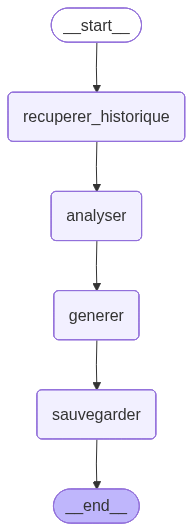

In [16]:
from IPython.display import Image, display

try:
    display(Image(graphe_v1.get_graph().draw_mermaid_png()))
except Exception:
    # Fallback texte si pas de connexion à mermaid
    print(graphe_v1.get_graph().draw_ascii())

### 5.5 Tester le graphe complet

In [17]:
# On reset Bob pour bien partir de zéro
conn = sqlite3.connect(DB_PATH)
conn.execute("DELETE FROM seances WHERE user_id = ?", ("bob",))
conn.commit()
conn.close()

# Premier appel
print("\n=== SÉANCE #1 de Bob ===")
result = graphe_v1.invoke({
    "user_id": "bob",
    "sport": "course",
    "duree_min": 5,
    "ressenti": "première fois, c'était dur mais je l'ai fait",
    "historique": [],
    "sentiment": None,
    "signaux_faibles": [],
    "ton_choisi": None,
    "message_final": None,
    "encouragement": None
})

print(f"\n Message final :\n   {result['message_final']}")
print(f" Ton : {result['ton_choisi']}")
print(f" À retenir : {result['encouragement']}")


=== SÉANCE #1 de Bob ===
   [historique] 0 séance(s) trouvée(s)
   [analyse] sentiment=neutre, signaux=['intensite_subjective_haute']
   [génération] ton=chaleureux
   [sauvegarde] séance enregistrée pour bob

 Message final :
   Bravo pour cette première séance ! 🎉 Tu as osé te lancer, et c’est déjà énorme. Écoute ton corps et prends le temps de progresser à ton rythme.
 Ton : chaleureux
 À retenir : Ta persévérance est bien plus importante que l’intensité de l’effort aujourd’hui.


C:\Users\maxch\AppData\Local\Temp\ipykernel_6948\2642331500.py:15: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  datetime.utcnow().isoformat()


---
##  Étape 6 — Routage conditionnel : 4 tons selon le contexte (45 min)

**Objectif** : c'est ICI que LangGraph devient indispensable. Selon les signaux détectés, on emprunte des chemins différents dans le graphe.

### Logique de routage qu'on veut implémenter

```
┌─────────────────────────────────────────────────────────────┐
│  Si "douleur_physique" dans signaux                         │
│      → ton ALERTE (suggérer repos, consulter un pro)        │
│                                                              │
│  Sinon, si historique vide                                   │
│      → ton CHALEUREUX (féliciter pour la première fois)     │
│                                                              │
│  Sinon, si 3+ séances avec sentiment négatif d'affilée      │
│      → ton DOUX (ne pas en rajouter, valoriser la régularité│
│                                                              │
│  Sinon                                                       │
│      → ton MOTIVANT (énergie, progression, défi positif)    │
└─────────────────────────────────────────────────────────────┘
```

### 6.1 Étendre l'état avec le ton imposé

In [18]:
class EtatCoachV2(TypedDict):
    user_id: str
    sport: str
    duree_min: int
    ressenti: str
    historique: List[dict]
    sentiment: Optional[str]
    signaux_faibles: List[str]
    ton_impose: Optional[str]   # NOUVEAU : décidé par le routeur, imposé au générateur
    message_final: Optional[str]
    encouragement: Optional[str]

### 6.2 La fonction de routage

Cette fonction lit l'état et renvoie le **nom du nœud suivant** à exécuter.

In [19]:
def router_selon_contexte(state: EtatCoachV2) -> str:
    """Décide quel ton appliquer selon les signaux et l'historique.

    Renvoie le NOM du prochain nœud à exécuter.
    """
    signaux = state.get("signaux_faibles", [])

    # Priorité absolue : douleur physique
    if "douleur_physique" in signaux:
        return "generer_alerte"

    # Première séance ?
    if len(state.get("historique", [])) == 0:
        return "generer_chaleureux"

    # 3 dernières séances toutes négatives ?
    historique = state.get("historique", [])
    if len(historique) >= 3:
        derniers_sentiments = [s.get("sentiment") for s in historique[:3]]
        if all(s == "negatif" for s in derniers_sentiments):
            return "generer_doux"

    # Cas par défaut : motivant
    return "generer_motivant"


# Test isolé du routeur
print("Test 1 — douleur :")
print(" →", router_selon_contexte({
    "signaux_faibles": ["douleur_physique"], "historique": []
}))

print("\nTest 2 — première séance :")
print(" →", router_selon_contexte({
    "signaux_faibles": ["aucun"], "historique": []
}))

print("\nTest 3 — 3 séances négatives :")
print(" →", router_selon_contexte({
    "signaux_faibles": ["aucun"],
    "historique": [{"sentiment": "negatif"}] * 3
}))

print("\nTest 4 — cas normal :")
print(" →", router_selon_contexte({
    "signaux_faibles": ["aucun"],
    "historique": [{"sentiment": "positif"}, {"sentiment": "neutre"}]
}))

Test 1 — douleur :
 → generer_alerte

Test 2 — première séance :
 → generer_chaleureux

Test 3 — 3 séances négatives :
 → generer_doux

Test 4 — cas normal :
 → generer_motivant


### 6.3 Quatre nœuds générateurs spécialisés

Chacun applique un système de prompt différent.

In [20]:
TONS_CONFIG = {
    "alerte": {
        "system": """Tu es un coach sportif RESPONSABLE. L'utilisateur mentionne une douleur.
- Reconnais cette douleur sans dramatiser
- Suggère du repos et la consultation d'un professionnel si nécessaire
- NE DONNE JAMAIS de diagnostic médical
- Reste chaleureux : la douleur n'est pas un échec
- 2-3 phrases max, ton calme et rassurant"""
    },
    "chaleureux": {
        "system": """Tu es un coach sportif qui accueille un GRAND DÉBUTANT (première séance).
- Félicite chaleureusement le passage à l'action
- Insiste sur le fait que démarrer est le plus dur
- Encourage à recommencer bientôt sans pression
- Ton chaleureux et bienveillant, 2-3 phrases, 1 emoji possible"""
    },
    "doux": {
        "system": """Tu es un coach sportif qui parle à un sportif découragé (3+ séances négatives).
- VALORISE LA RÉGULARITÉ avant tout (continuer malgré la difficulté = exploit)
- Ne fais PAS de promesse de progrès rapide
- Suggère doucement de varier ou ralentir le rythme
- Ton très doux, sans excès d'enthousiasme, 2-3 phrases, sans emoji"""
    },
    "motivant": {
        "system": """Tu es un coach sportif énergique qui parle à un sportif régulier.
- Célèbre l'effort accompli avec énergie
- Souligne la progression si possible (par rapport à l'historique)
- Lance un petit défi positif pour la prochaine fois
- Ton dynamique et motivant, 2-3 phrases, 1-2 emojis"""
    }
}

def generer_message_avec_ton(state: EtatCoachV2, ton: str) -> dict:
    """Génère un message avec un ton imposé."""
    config = TONS_CONFIG[ton]

    if state["historique"]:
        resume_hist = "\n".join(
            f"- {s['sport']} {s['duree_min']}min ({s.get('sentiment','?')}): {s['ressenti'][:60]}"
            for s in state["historique"][:3]
        )
    else:
        resume_hist = "(aucune séance précédente)"

    prompt = ChatPromptTemplate.from_messages([
        ("system", config["system"]),
        ("human", """Séance: {sport} pendant {duree} min.
Ressenti: « {ressenti} »
Signaux détectés: {signaux}
Historique:
{historique}

Rédige le message.""")
    ])

    chaine = prompt | llm.with_structured_output(ReponseCoach)
    rep = chaine.invoke({
        "sport": state["sport"], "duree": state["duree_min"],
        "ressenti": state["ressenti"],
        "signaux": ", ".join(state["signaux_faibles"]),
        "historique": resume_hist
    })

    print(f"   [{ton}] {rep.message[:80]}...")
    return {
        "ton_impose": ton,
        "message_final": rep.message,
        "encouragement": rep.encouragement_principal
    }

# Wrappers pour chaque ton (LangGraph appelle ces fonctions par leur nom)
def n_generer_alerte(s):    return generer_message_avec_ton(s, "alerte")
def n_generer_chaleureux(s): return generer_message_avec_ton(s, "chaleureux")
def n_generer_doux(s):      return generer_message_avec_ton(s, "doux")
def n_generer_motivant(s):  return generer_message_avec_ton(s, "motivant")

### 6.4 Construire le graphe v2 avec routage conditionnel

In [1]:
builder2 = StateGraph(EtatCoachV2)

# Nœuds réutilisés de la v1
builder2.add_node("recuperer_historique", noeud_recuperer_historique)
builder2.add_node("analyser", noeud_analyser_ressenti)

# Nouveaux nœuds : un par ton
builder2.add_node("generer_alerte", n_generer_alerte)
builder2.add_node("generer_chaleureux", n_generer_chaleureux)
builder2.add_node("generer_doux", n_generer_doux)
builder2.add_node("generer_motivant", n_generer_motivant)

# Sauvegarde adaptée à la v2
def noeud_sauvegarder_v2(state: EtatCoachV2) -> dict:
    enregistrer_seance(
        user_id=state["user_id"], sport=state["sport"],
        duree_min=state["duree_min"], ressenti=state["ressenti"],
        sentiment=state["sentiment"], signaux=state["signaux_faibles"],
        ton=state["ton_impose"], message=state["message_final"]
    )
    return {}

builder2.add_node("sauvegarder", noeud_sauvegarder_v2)

# Arêtes
builder2.add_edge(START, "recuperer_historique")
builder2.add_edge("recuperer_historique", "analyser")

#  ARÊTE CONDITIONNELLE : c'est ici que le routage opère
builder2.add_conditional_edges(
    "analyser",
    router_selon_contexte,  # la fonction de routage
    {
        "generer_alerte": "generer_alerte",
        "generer_chaleureux": "generer_chaleureux",
        "generer_doux": "generer_doux",
        "generer_motivant": "generer_motivant"
    }
)

# Tous les générateurs convergent vers la sauvegarde
for nom in ["generer_alerte", "generer_chaleureux", "generer_doux", "generer_motivant"]:
    builder2.add_edge(nom, "sauvegarder")

builder2.add_edge("sauvegarder", END)

graphe_v2 = builder2.compile()
print(" Graphe v2 (routage conditionnel) compilé")

NameError: name 'StateGraph' is not defined

### 6.5 Visualiser le graphe v2

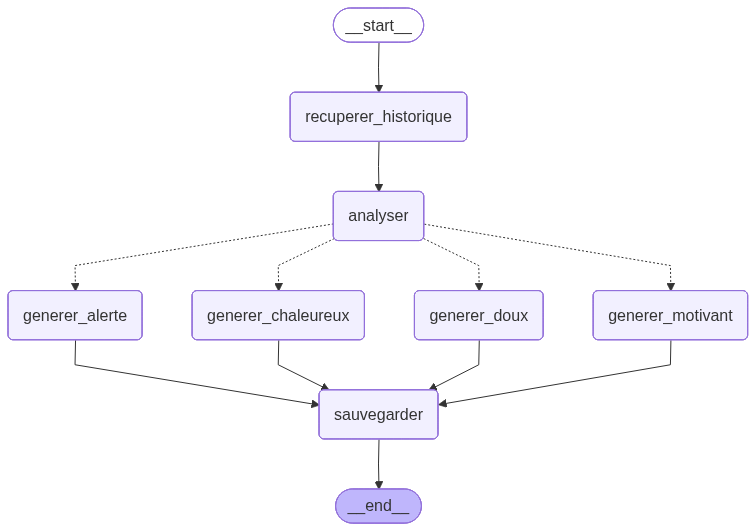

In [22]:
display(Image(graphe_v2.get_graph().draw_mermaid_png()))

### 6.6 Tester les 4 chemins

On crée des scénarios qui forcent chaque chemin du graphe.

In [23]:
def lancer_seance(user_id, sport, duree, ressenti):
    """Helper pour lancer le graphe v2 proprement."""
    return graphe_v2.invoke({
        "user_id": user_id, "sport": sport,
        "duree_min": duree, "ressenti": ressenti,
        "historique": [], "sentiment": None,
        "signaux_faibles": [], "ton_impose": None,
        "message_final": None, "encouragement": None
    })

# Reset Charlie
conn = sqlite3.connect(DB_PATH)
conn.execute("DELETE FROM seances WHERE user_id = ?", ("charlie",))
conn.commit()
conn.close()

# === Test 1 : première séance → CHALEUREUX ===
print("\n" + "="*60)
print("TEST 1 — Première séance (devrait être CHALEUREUX)")
print("="*60)
r1 = lancer_seance("charlie", "course", 5, "première fois, c'était dur")
print(f"\n>>> Ton appliqué : {r1['ton_impose']}")
print(f">>> Message : {r1['message_final']}")


TEST 1 — Première séance (devrait être CHALEUREUX)
   [historique] 0 séance(s) trouvée(s)
   [analyse] sentiment=negatif, signaux=['intensite_subjective_haute']
   [chaleureux] Félicitations pour cette première séance, c’est déjà énorme d’avoir osé te lance...

>>> Ton appliqué : chaleureux
>>> Message : Félicitations pour cette première séance, c’est déjà énorme d’avoir osé te lancer ! C’est normal que ce soit intense au début, mais chaque pas compte. On se retrouve vite pour une prochaine session, sans pression, juste pour progresser ensemble 💪.


C:\Users\maxch\AppData\Local\Temp\ipykernel_6948\2642331500.py:15: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  datetime.utcnow().isoformat()


In [24]:
# === Test 2 : douleur → ALERTE (peu importe le reste) ===
print("\n" + "="*60)
print("TEST 2 — Mention de douleur (devrait être ALERTE)")
print("="*60)
r2 = lancer_seance("charlie", "course", 10, "ça allait mais maintenant j'ai mal au genou")
print(f"\n>>> Ton appliqué : {r2['ton_impose']}")
print(f">>> Message : {r2['message_final']}")


TEST 2 — Mention de douleur (devrait être ALERTE)
   [historique] 1 séance(s) trouvée(s)
   [analyse] sentiment=negatif, signaux=['douleur_physique']
   [alerte] Je comprends que ton genou te fasse un peu souffrir après cette séance. C’est im...

>>> Ton appliqué : alerte
>>> Message : Je comprends que ton genou te fasse un peu souffrir après cette séance. C’est important d’écouter ton corps : prends un peu de repos et si la douleur persiste, consulte un professionnel de santé pour être sûr que tout va bien. La douleur n’est pas un échec, c’est un signal à respecter.


C:\Users\maxch\AppData\Local\Temp\ipykernel_6948\2642331500.py:15: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  datetime.utcnow().isoformat()


In [25]:
# === Test 3 : pour avoir le DOUX, on simule 3 séances négatives passées ===
# On insère manuellement 3 séances avec sentiment négatif pour Diane
conn = sqlite3.connect(DB_PATH)
conn.execute("DELETE FROM seances WHERE user_id = ?", ("diane",))
conn.commit()
conn.close()

for sport, ressenti in [
    ("tennis", "j'arrive à rien"),
    ("tennis", "je suis nulle"),
    ("course", "trop dur, je vais arrêter")
]:
    enregistrer_seance("diane", sport, 10, ressenti, sentiment="negatif", signaux=["demotivation"])

print("\n" + "="*60)
print("TEST 3 — 3 séances négatives passées (devrait être DOUX)")
print("="*60)
r3 = lancer_seance("diane", "course", 12, "encore une fois, c'était dur")
print(f"\n>>> Ton appliqué : {r3['ton_impose']}")
print(f">>> Message : {r3['message_final']}")

C:\Users\maxch\AppData\Local\Temp\ipykernel_6948\2642331500.py:15: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  datetime.utcnow().isoformat()



TEST 3 — 3 séances négatives passées (devrait être DOUX)
   [historique] 3 séance(s) trouvée(s)
   [analyse] sentiment=negatif, signaux=['intensite_subjective_haute']
   [doux] Ces séances demandent beaucoup d’énergie, et le fait de continuer malgré tout mo...

>>> Ton appliqué : doux
>>> Message : Ces séances demandent beaucoup d’énergie, et le fait de continuer malgré tout montre une vraie persévérance. Peut-être que ralentir un peu ou varier les activités pourrait t’aider à retrouver du plaisir sans te sentir submergée.


C:\Users\maxch\AppData\Local\Temp\ipykernel_6948\2642331500.py:15: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  datetime.utcnow().isoformat()


In [26]:
# === Test 4 : utilisateur régulier avec une bonne séance → MOTIVANT ===
conn = sqlite3.connect(DB_PATH)
conn.execute("DELETE FROM seances WHERE user_id = ?", ("ethan",))
conn.commit()
conn.close()

# On lui donne 2 séances passées variées
enregistrer_seance("ethan", "course", 15, "ça va", sentiment="positif")
enregistrer_seance("ethan", "vélo", 30, "super", sentiment="positif")

print("\n" + "="*60)
print("TEST 4 — Sportif régulier, séance positive (devrait être MOTIVANT)")
print("="*60)
r4 = lancer_seance("ethan", "course", 20, "j'ai battu mon record !")
print(f"\n>>> Ton appliqué : {r4['ton_impose']}")
print(f">>> Message : {r4['message_final']}")

C:\Users\maxch\AppData\Local\Temp\ipykernel_6948\2642331500.py:15: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  datetime.utcnow().isoformat()



TEST 4 — Sportif régulier, séance positive (devrait être MOTIVANT)
   [historique] 2 séance(s) trouvée(s)
   [analyse] sentiment=positif, signaux=['aucun']
   [motivant] Wow, 20 minutes de course et un record battu ?! 🎉 Tu es en feu, champion ! La pr...

>>> Ton appliqué : motivant
>>> Message : Wow, 20 minutes de course et un record battu ?! 🎉 Tu es en feu, champion ! La progression est clairement au rendez-vous, continue comme ça ! Pour la prochaine fois, essaie de tenir 22 minutes sans te décourager, tu vas encore tout écraser !


C:\Users\maxch\AppData\Local\Temp\ipykernel_6948\2642331500.py:15: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  datetime.utcnow().isoformat()


---
##  Bilan de la Partie 1

Vous avez construit un **agent IA complet** qui :

-  Reçoit une séance utilisateur
-  Analyse le ressenti via Pydantic + LLM
-  Détecte des signaux faibles (douleur, démotivation…)
-  Lit l'historique persistant en SQLite
-  Choisit dynamiquement entre 4 tons de coaching
-  Génère un message bienveillant et adapté
-  Sauvegarde la séance pour les prochaines décisions

### Compétences mobilisées (CDA2.2)

| Compétence | Où dans le notebook |
|---|---|
| Concevoir des requêtes SQL | Étape 4 (CRUD SQLite) |
| Utiliser un service web | Étape 1+ (API Mistral via LangChain) |
| Architecture d'application | Étapes 2-3 (séparation analyse/génération) |
| Définir des structures de données | Étape 2 (Pydantic), Étape 5 (TypedDict) |

###  Ce qu'il vous reste à faire

️ **Partie 2 — FastAPI** (`TP_Coach_IA_FastAPI.md`, ~2h30) :
- Réorganiser ce code en architecture en couches
- Exposer un endpoint POST /seance
- Documenter automatiquement avec OpenAPI
- Tester avec Postman et Pytest
- Déployer sur Render

>  **Astuce** : tout le code de ce notebook va être réutilisé dans FastAPI. Vous ne réécrirez quasiment rien — juste l'organiserez. C'est ça, la promesse de l'architecture en couches.

---

**Bravo, vous avez construit votre premier agent IA agentique !** 